<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance Course

**Module 1 &mdash; Financial Data**

[team@tpq.io](mailto:team@tpq.io) | [http://tpq.io](http://tpq.io)

The Python Quants GmbH

## Requirements

Make sure to have installed locally a **comprehensive Python installation** like the [Anaconda](http://repo.continuum.io) Python distribution (code Python 3.6 tested).

Alternatively, and more easily, register on the **[Quant Platform](http://pqp.io)** where you can execute this Jupyter Notebook file in the browser. After registration, you find all Jupyter Notebook files of this course in the folder `pffcourse`.

## Necessary Imports

Working with Python in general requires you to **import certain modules/packages** from the standard library or from the so-called scientific or PyData stack (i.e. from third parties).

In [1]:
import numpy as np  # array operations
import pandas as pd  # time series management
from pylab import plt
plt.style.use('ggplot')
# put all plots in the notebook itself
%matplotlib inline

## Retrieving Stock Price Data

We retrieve **end-of-day (EOD) price data** for certain instruments (data source: Thomson Reuters Eikon API).

In [2]:
data = pd.read_csv('http://hilpisch.com/tr_eikon_eod_data.csv',
                   index_col=0, parse_dates=True)

The `AAPL` object is of **type** `DataFrame`.

In [3]:
type(data)

pandas.core.frame.DataFrame

`DataFrame` objects provide a **wealth of (convenience) methods**.

In [4]:
data.info()  # meta information

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
AAPL.O    2138 non-null float64
MSFT.O    2138 non-null float64
INTC.O    2138 non-null float64
AMZN.O    2138 non-null float64
GS.N      2138 non-null float64
SPY       2138 non-null float64
.SPX      2138 non-null float64
.VIX      2138 non-null float64
EUR=      2216 non-null float64
XAU=      2211 non-null float64
GDX       2138 non-null float64
GLD       2138 non-null float64
dtypes: float64(12)
memory usage: 225.1 KB


## Working with the Data

Let us inspect the **final five rows** of the data set.

In [5]:
data.tail()  # final five rows

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2018-06-25,182.17,98.39,50.71,1663.15,221.54,271.00,2717.07,17.33,1.1702,1265.00,22.01,119.89
2018-06-26,184.43,99.08,49.67,1691.09,221.58,271.60,2723.06,15.92,1.1645,1258.64,21.95,119.26
2018-06-27,184.16,97.54,48.76,1660.51,220.18,269.35,2699.63,17.91,1.1552,1251.62,21.81,118.58
2018-06-28,185.50,98.63,49.25,1701.45,223.42,270.89,2716.31,16.85,1.1567,1247.88,21.93,118.22
2018-06-29,185.11,98.61,49.71,1699.80,220.57,271.28,2718.37,16.09,1.1683,1252.25,22.31,118.65


You can easily **select single or multiple columns** of a `DataFrame` object.

In [6]:
data['AAPL.O'].head()  # first five rows of single column

Date
2010-01-01          NaN
2010-01-04    30.572827
2010-01-05    30.625684
2010-01-06    30.138541
2010-01-07    30.082827
Name: AAPL.O, dtype: float64

In [7]:
data[['AAPL.O', 'MSFT.O']].tail()  # last five rows of 2 columns

,AAPL.O,MSFT.O
Date,,
2018-06-25,182.17,98.39
2018-06-26,184.43,99.08
2018-06-27,184.16,97.54
2018-06-28,185.50,98.63
2018-06-29,185.11,98.61


Similarly, you can select **single or multiple rows**.

In [8]:
data.loc['2017-10-06']  # single row via index value

AAPL.O     155.3000
MSFT.O      76.0000
INTC.O      39.6300
AMZN.O     989.5800
GS.N       246.0200
SPY        254.3700
.SPX      2549.3300
.VIX         9.6500
EUR=         1.1733
XAU=      1275.3000
GDX         23.5900
GLD        121.0900
Name: 2017-10-06 00:00:00, dtype: float64

In [9]:
data.iloc[:2]  # two rows via index numbers

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4323,1096.35,NaN,NaN
2010-01-04,30.572827,30.95,20.88,133.9,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.8


## Data Visualization

There is also a powerful **method for plotting**.

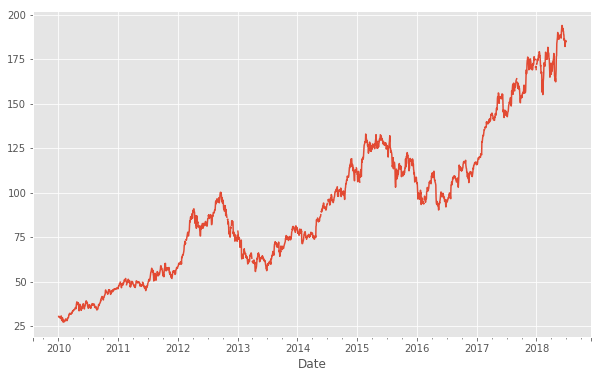

In [10]:
data['AAPL.O'].plot(figsize=(10, 6));

Let us calculate the Apple stock price **log returns**.

In [11]:
# fully vectorized operation for log return calculation
rets = np.log(data['AAPL.O'] / data['AAPL.O'].shift(1))

The log returns can then be visualized via a **histogram**.

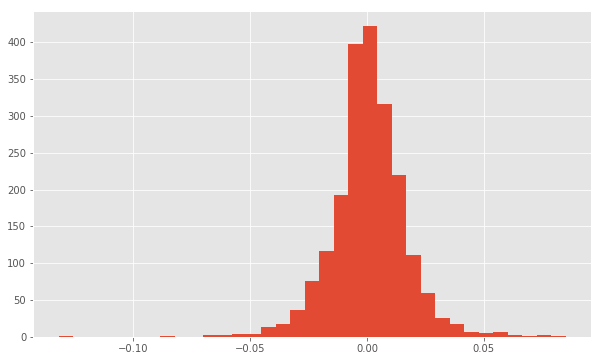

In [12]:
rets.hist(figsize=(10, 6), bins=35);

## Calculating a Moving Average

pandas provides, among others, convenience functions for the calculation of **moving averages**.

In [13]:
# fully vectorized calculation of 50 days moving average/trend
data['MA50'] = data['AAPL.O'].rolling(50).mean()

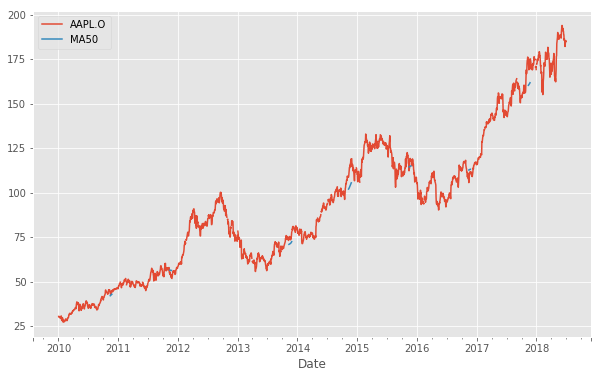

In [14]:
data[['AAPL.O', 'MA50']].plot(figsize=(10, 6));

## Closing Remarks

This closes the first module of the Python for Finance email course. In this module, you have learned:

* how to retrieve stock price data with pandas (datareader)
* how to look up information about and data stored in a `DataFrame` object
* how to select columns and rows from a `DataFrame` object
* how to visulize data stored in a `DataFrame` object
* how to do vectorized calculations with `DataFrame` objects (log returns, moving average)

What you have learned today builds the basis for many important use cases for Python in Finance.

## Exercises

In order to master the material of this module, do the following:

* replace Apple by another symbol, eg. `MSFT.O` or `.SPX`
* read the **10 Minutes to pandas** tutorial under http://pandas.pydata.org/pandas-docs/stable/10min.html
* discover plotting options under http://pandas.pydata.org/pandas-docs/stable/visualization.html
* calculate other statics with e.g. `.rolling(window=X).std()` or `.rolling(window=X).max()`
* discover more computational tools of pandas under http://pandas.pydata.org/pandas-docs/stable/computation.html

## References

You find background information for the topics covered in this module in the following books:

* Hilpisch, Yves (2018): _Python for Finance_. 2nd ed, O'Reilly, ch. 8.
* McKinney, Wes (2012): _Python for Data Analysis_. O'Reilly.
* VanderPlas, Jake (2016): _Python Data Science Handbook_. O'Reilly.

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>

**Quant Platform** |
<a href="http://quant-platform.com">http://quant-platform.com</a>

**Python for Finance** |
<a href="http://python-for-finance.com" target="_blank">Python for Finance @ O'Reilly</a>

**Derivatives Analytics with Python** |
<a href="http://derivatives-analytics-with-python.com" target="_blank">Derivatives Analytics @ Wiley Finance</a>

**Listed Volatility and Variance Derivatives** |
<a href="http://lvvd.tpq.io" target="_blank">Listed VV Derivatives @ Wiley Finance</a>